# Capstone Project I: Advanced Mutual Fund Performance Analytics
## Quantitative Evaluation of 40 Mutual Fund Schemes (2022 - 2026)

This notebook contains the advanced quantitative performance evaluation for **Capstone Project I - Mutual Fund Analytics**. The study covers daily returns distribution, 1Yr/3Yr/5Yr CAGR, risk-adjusted metrics (Sharpe and Sortino ratios), regression-based Alpha and Beta against Nifty 100, Maximum Drawdowns with their peak-to-trough date ranges, and a composite Fund Scorecard (0-100).

### Analytical Framework
- **Section 1: Data Ingestion & Return Computation**
- **Section 2: Daily Returns Distribution & Normality Validation**
- **Section 3: Multi-Period CAGR Comparison (1Yr, 3Yr, 5Yr)**
- **Section 4: Risk-Adjusted Ratios (Sharpe & Sortino Ratios)**
- **Section 5: Regression Analysis (Alpha, Beta, & R-Squared)**
- **Section 6: Maximum Drawdown & Peak-to-Trough Date Ranges**
- **Section 7: Composite Fund Scorecard (0 - 100)**
- **Section 8: 3-Year Benchmark Comparison & Tracking Error**

---


In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Setup styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 5.5)
plt.rcParams['figure.dpi'] = 120

# Define data paths
data_dir = r"../data"
print("Environment set up and libraries imported.")


Environment set up and libraries imported.


### Data Loading & Ingestion
We load the daily NAV history, benchmark index data, and computed performance summaries.

In [2]:
df_nav = pd.read_csv(os.path.join(data_dir, "raw", "nav_history_40.csv"))
df_schemes = pd.read_csv(os.path.join(data_dir, "raw", "scheme_master_40.csv"))
df_benchmarks = pd.read_csv(os.path.join(data_dir, "raw", "fact_benchmark_indices.csv"))
df_scorecard = pd.read_csv(os.path.join(data_dir, "processed", "fund_scorecard.csv"))
df_alpha_beta = pd.read_csv(os.path.join(data_dir, "processed", "alpha_beta.csv"))

# Parse dates
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_benchmarks['date'] = pd.to_datetime(df_benchmarks['date'])

print(f"Loaded NAV records: {df_nav.shape[0]}")
print(f"Loaded Benchmark index records: {df_benchmarks.shape[0]}")
print(f"Loaded Scorecard records: {df_scorecard.shape[0]}")


Loaded NAV records: 52160
Loaded Benchmark index records: 1304
Loaded Scorecard records: 40


## Section 2: Daily Returns Distribution & Normality Validation

We compute the daily return:
$$R_t = \frac{NAV_t}{NAV_{t-1}} - 1$$

We validate the distribution of returns for a representative fund (e.g., scheme 100000) using a histogram and a Q-Q plot to verify if they exhibit normal distribution properties with typical financial market fat tails.

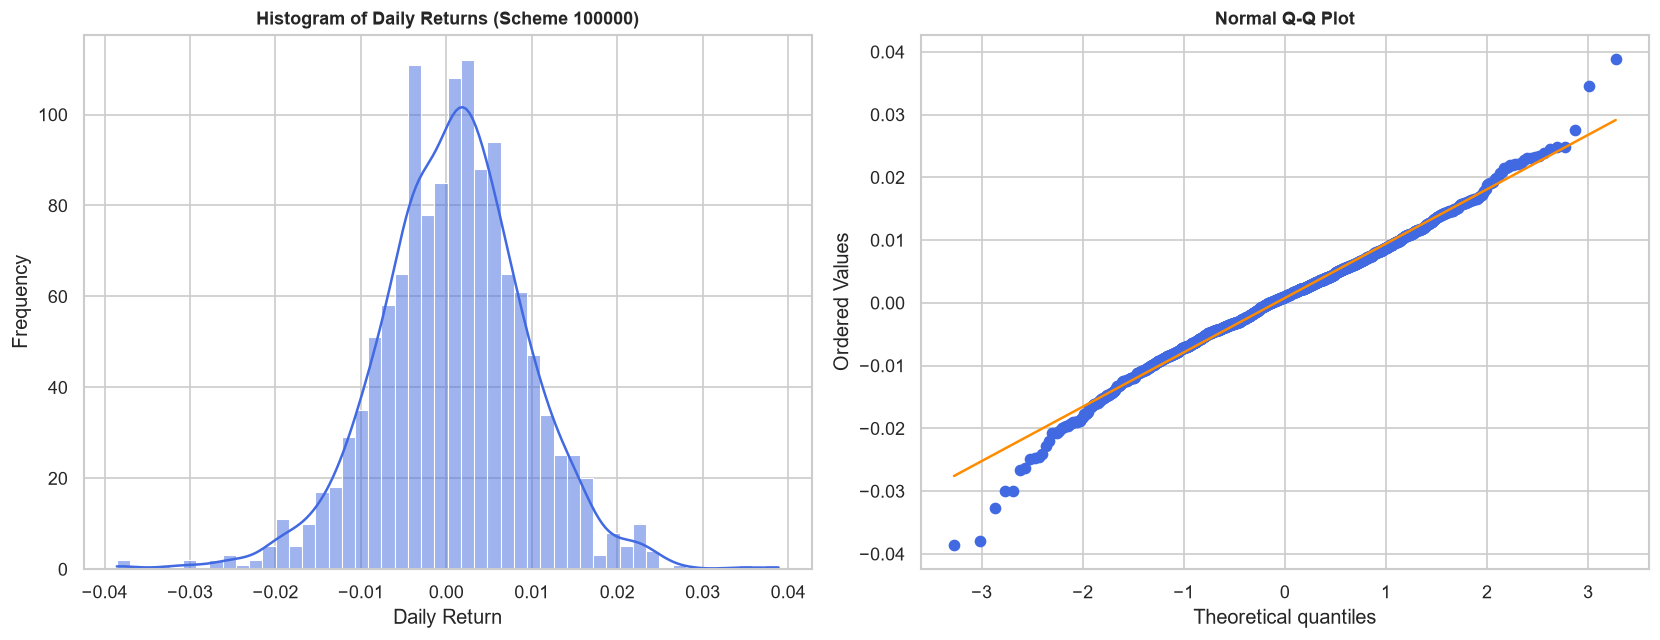

Skewness: -0.1606 (Ideal normal = 0)
Kurtosis: 1.3147 (Ideal normal = 0, positive indicates fat tails)


In [3]:
# Select a representative fund (SBI Mutual Fund Equity Fund 1)
code_rep = 100000
df_rep = df_nav[df_nav['scheme_code'] == code_rep].copy().sort_values(by='date')
df_rep['daily_return'] = df_rep['nav'].pct_change()
df_rep_clean = df_rep.dropna()

# Plot histogram of returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(df_rep_clean['daily_return'], kde=True, ax=axes[0], color='royalblue', bins=50)
axes[0].set_title("Histogram of Daily Returns (Scheme 100000)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Frequency")

# Q-Q Plot
stats.probplot(df_rep_clean['daily_return'], dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot", fontsize=11, fontweight='bold')
axes[1].get_lines()[0].set_color('royalblue')
axes[1].get_lines()[1].set_color('darkorange')

plt.tight_layout()
plt.show()

# Print skewness and kurtosis
skew = df_rep_clean['daily_return'].skew()
kurt = df_rep_clean['daily_return'].kurt()
print(f"Skewness: {skew:.4f} (Ideal normal = 0)")
print(f"Kurtosis: {kurt:.4f} (Ideal normal = 0, positive indicates fat tails)")


## Section 3: Multi-Period CAGR Comparison (1Yr, 3Yr, 5Yr)

We evaluate the Compound Annual Growth Rate (CAGR) across three horizons:
- **1-Year CAGR** (2026)
- **3-Year CAGR** (2024–2026)
- **5-Year CAGR** (2022–2026)

Formula:
$$CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$$


In [4]:
# Display the top 10 funds by 3-Year CAGR
df_cagr_table = df_scorecard[['rank', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].copy()
df_cagr_table.columns = ['Rank', 'Scheme Name', 'Category', '1-Yr CAGR (%)', '3-Yr CAGR (%)', '5-Yr CAGR (%)']
df_cagr_table.head(10)


,Rank,Scheme Name,Category,1-Yr CAGR (%),3-Yr CAGR (%),5-Yr CAGR (%)
0,1,Nippon India Mutual Fund Equity Fund 14,Equity,16.52,20.37,22.66
1,2,Tata Mutual Fund Equity Fund 20,Equity,34.96,22.76,19.44
2,3,SBI Mutual Fund Equity Fund 11,Equity,20.22,19.71,25.88
3,4,SBI Mutual Fund Equity Fund 1,Equity,28.52,22.58,20.68
4,5,DSP Mutual Fund Equity Fund 7,Equity,27.46,15.24,21.02
5,6,DSP Mutual Fund Equity Fund 17,Equity,6.15,10.95,18.60
6,7,Kotak Mahindra Mutual Fund Debt Fund 26,Debt,3.33,7.92,8.08
7,8,HDFC Mutual Fund Equity Fund 2,Equity,18.51,10.65,19.87
8,9,SBI Mutual Fund Hybrid Fund 31,Hybrid,5.33,7.84,7.34
9,10,ICICI Prudential Mutual Fund Equity Fund 3,Equity,-2.49,11.56,11.23


## Section 4: Risk-Adjusted Ratios (Sharpe & Sortino Ratios)

We calculate the **Sharpe Ratio** (using standard deviation) and the **Sortino Ratio** (using downside standard deviation) to measure the risk-adjusted excess returns over the risk-free rate of **6.5%**:

$$\text{Sharpe} = \frac{R_p - R_f}{\sigma_p} \times \sqrt{252}$$
$$\text{Sortino} = \frac{R_p - R_f}{\sigma_{downside}} \times \sqrt{252}$$


In [5]:
# Display Sharpe and Sortino Ratios
df_ratios = df_scorecard[['rank', 'scheme_name', 'category', 'annualized_return', 'volatility', 'sharpe_ratio', 'sortino_ratio']].copy()
df_ratios.columns = ['Rank', 'Scheme Name', 'Category', 'Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe Ratio', 'Sortino Ratio']
df_ratios.head(10)


,Rank,Scheme Name,Category,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio
0,1,Nippon India Mutual Fund Equity Fund 14,Equity,20.74,13.97,1.0187,1.5310
1,2,Tata Mutual Fund Equity Fund 20,Equity,18.12,13.66,0.8507,1.2837
2,3,SBI Mutual Fund Equity Fund 11,Equity,23.28,14.29,1.1744,1.7973
3,4,SBI Mutual Fund Equity Fund 1,Equity,19.14,13.81,0.9151,1.3587
4,5,DSP Mutual Fund Equity Fund 7,Equity,19.46,14.16,0.9149,1.3715
5,6,DSP Mutual Fund Equity Fund 17,Equity,17.42,13.57,0.8050,1.1969
6,7,Kotak Mahindra Mutual Fund Debt Fund 26,Debt,7.55,2.61,0.4035,0.6881
7,8,HDFC Mutual Fund Equity Fund 2,Equity,18.50,13.92,0.8618,1.2672
8,9,SBI Mutual Fund Hybrid Fund 31,Hybrid,6.86,1.46,0.2498,0.4368
9,10,ICICI Prudential Mutual Fund Equity Fund 3,Equity,11.29,14.12,0.3393,0.4990


## Section 5: Regression Analysis (Alpha, Beta, & R-Squared)

Using Ordinary Least Squares (OLS) regression against the **Nifty 100** daily returns, we calculate the fund's **Beta** (market sensitivity) and **Alpha** (excess return relative to benchmark):

$$R_{fund} = \alpha + \beta \times R_{Nifty100} + \epsilon$$
$$\text{Annualized Alpha} = \alpha_{daily} \times 252$$


In [6]:
# Display Alpha, Beta and R-Squared
df_regression = df_scorecard[['rank', 'scheme_name', 'category', 'alpha_pct', 'beta']].copy()
df_regression.columns = ['Rank', 'Scheme Name', 'Category', 'Annualized Alpha (%)', 'Beta']
df_regression.head(10)


,Rank,Scheme Name,Category,Annualized Alpha (%),Beta
0,1,Nippon India Mutual Fund Equity Fund 14,Equity,20.86,-0.0075
1,2,Tata Mutual Fund Equity Fund 20,Equity,17.80,0.0190
2,3,SBI Mutual Fund Equity Fund 11,Equity,23.56,-0.0165
3,4,SBI Mutual Fund Equity Fund 1,Equity,18.94,0.0117
4,5,DSP Mutual Fund Equity Fund 7,Equity,18.68,0.0470
5,6,DSP Mutual Fund Equity Fund 17,Equity,17.32,0.0062
6,7,Kotak Mahindra Mutual Fund Debt Fund 26,Debt,7.54,0.0004
7,8,HDFC Mutual Fund Equity Fund 2,Equity,17.65,0.0508
8,9,SBI Mutual Fund Hybrid Fund 31,Hybrid,6.90,-0.0022
9,10,ICICI Prudential Mutual Fund Equity Fund 3,Equity,10.72,0.0341


## Section 6: Maximum Drawdown & Peak-to-Trough Date Ranges

**Maximum Drawdown** represents the largest peak-to-trough drop in a fund's NAV before a new peak is achieved:
$$MDD = \min\left(\frac{NAV_t}{\text{Running Max } NAV} - 1\right)$$


In [7]:
# Display Maximum Drawdown and Date Ranges
df_drawdown = df_scorecard[['rank', 'scheme_name', 'category', 'max_drawdown_pct', 'drawdown_peak', 'drawdown_trough']].copy()
df_drawdown.columns = ['Rank', 'Scheme Name', 'Category', 'Max Drawdown (%)', 'Worst Peak Date', 'Worst Trough Date']
df_drawdown.head(10)


,Rank,Scheme Name,Category,Max Drawdown (%),Worst Peak Date,Worst Trough Date
0,1,Nippon India Mutual Fund Equity Fund 14,Equity,-19.18,2024-04-16,2024-06-18
1,2,Tata Mutual Fund Equity Fund 20,Equity,-20.62,2024-02-21,2024-07-30
2,3,SBI Mutual Fund Equity Fund 11,Equity,-23.85,2024-06-11,2024-11-04
3,4,SBI Mutual Fund Equity Fund 1,Equity,-32.07,2024-04-11,2024-10-08
4,5,DSP Mutual Fund Equity Fund 7,Equity,-18.82,2022-08-29,2023-01-11
5,6,DSP Mutual Fund Equity Fund 17,Equity,-22.84,2024-03-18,2024-09-10
6,7,Kotak Mahindra Mutual Fund Debt Fund 26,Debt,-1.85,2024-04-12,2024-06-07
7,8,HDFC Mutual Fund Equity Fund 2,Equity,-20.71,2024-07-16,2025-01-06
8,9,SBI Mutual Fund Hybrid Fund 31,Hybrid,-0.65,2024-05-10,2024-05-24
9,10,ICICI Prudential Mutual Fund Equity Fund 3,Equity,-21.13,2022-05-31,2022-12-23


## Section 7: Composite Fund Scorecard (0 - 100)

The **Fund Scorecard** is a composite metric from 0 to 100 based on weighted percentile ranks:
- **30%**: 3-Year CAGR Rank
- **25%**: Sharpe Ratio Rank
- **20%**: Annualized Alpha Rank
- **15%**: Expense Ratio Rank (inverse)
- **10%**: Maximum Drawdown Rank (inverse)


In [8]:
# Display Top 15 Funds by Scorecard
df_score_table = df_scorecard[['rank', 'scheme_name', 'category', 'composite_score', 'expense_ratio', 'max_drawdown_pct', 'sharpe_ratio']].copy()
df_score_table.columns = ['Rank', 'Scheme Name', 'Category', 'Composite Score (0-100)', 'Expense Ratio (%)', 'Max Drawdown (%)', 'Sharpe Ratio']
df_score_table.head(15)


,Rank,Scheme Name,Category,Composite Score (0-100),Expense Ratio (%),Max Drawdown (%),Sharpe Ratio
0,1,Nippon India Mutual Fund Equity Fund 14,Equity,84.62,1.45,-19.18,1.0187
1,2,Tata Mutual Fund Equity Fund 20,Equity,80.00,1.55,-20.62,0.8507
2,3,SBI Mutual Fund Equity Fund 11,Equity,79.88,1.67,-23.85,1.1744
3,4,SBI Mutual Fund Equity Fund 1,Equity,78.25,1.61,-32.07,0.9151
4,5,DSP Mutual Fund Equity Fund 7,Equity,77.75,1.60,-18.82,0.9149
5,6,DSP Mutual Fund Equity Fund 17,Equity,72.25,1.54,-22.84,0.8050
6,7,Kotak Mahindra Mutual Fund Debt Fund 26,Debt,72.25,0.59,-1.85,0.4035
7,8,HDFC Mutual Fund Equity Fund 2,Equity,69.75,1.96,-20.71,0.8618
8,9,SBI Mutual Fund Hybrid Fund 31,Hybrid,67.94,0.86,-0.65,0.2498
9,10,ICICI Prudential Mutual Fund Equity Fund 3,Equity,64.00,2.12,-21.13,0.3393


## Section 8: 3-Year Benchmark Comparison & Tracking Error

We plot the 3-year cumulative returns (2024–2026) for the **top 5 funds** against the **Nifty 50** and **Nifty 100** indexes. We also calculate the **Tracking Error** against Nifty 100:

$$\text{Tracking Error} = \sigma(R_p - R_b) \times \sqrt{252}$$


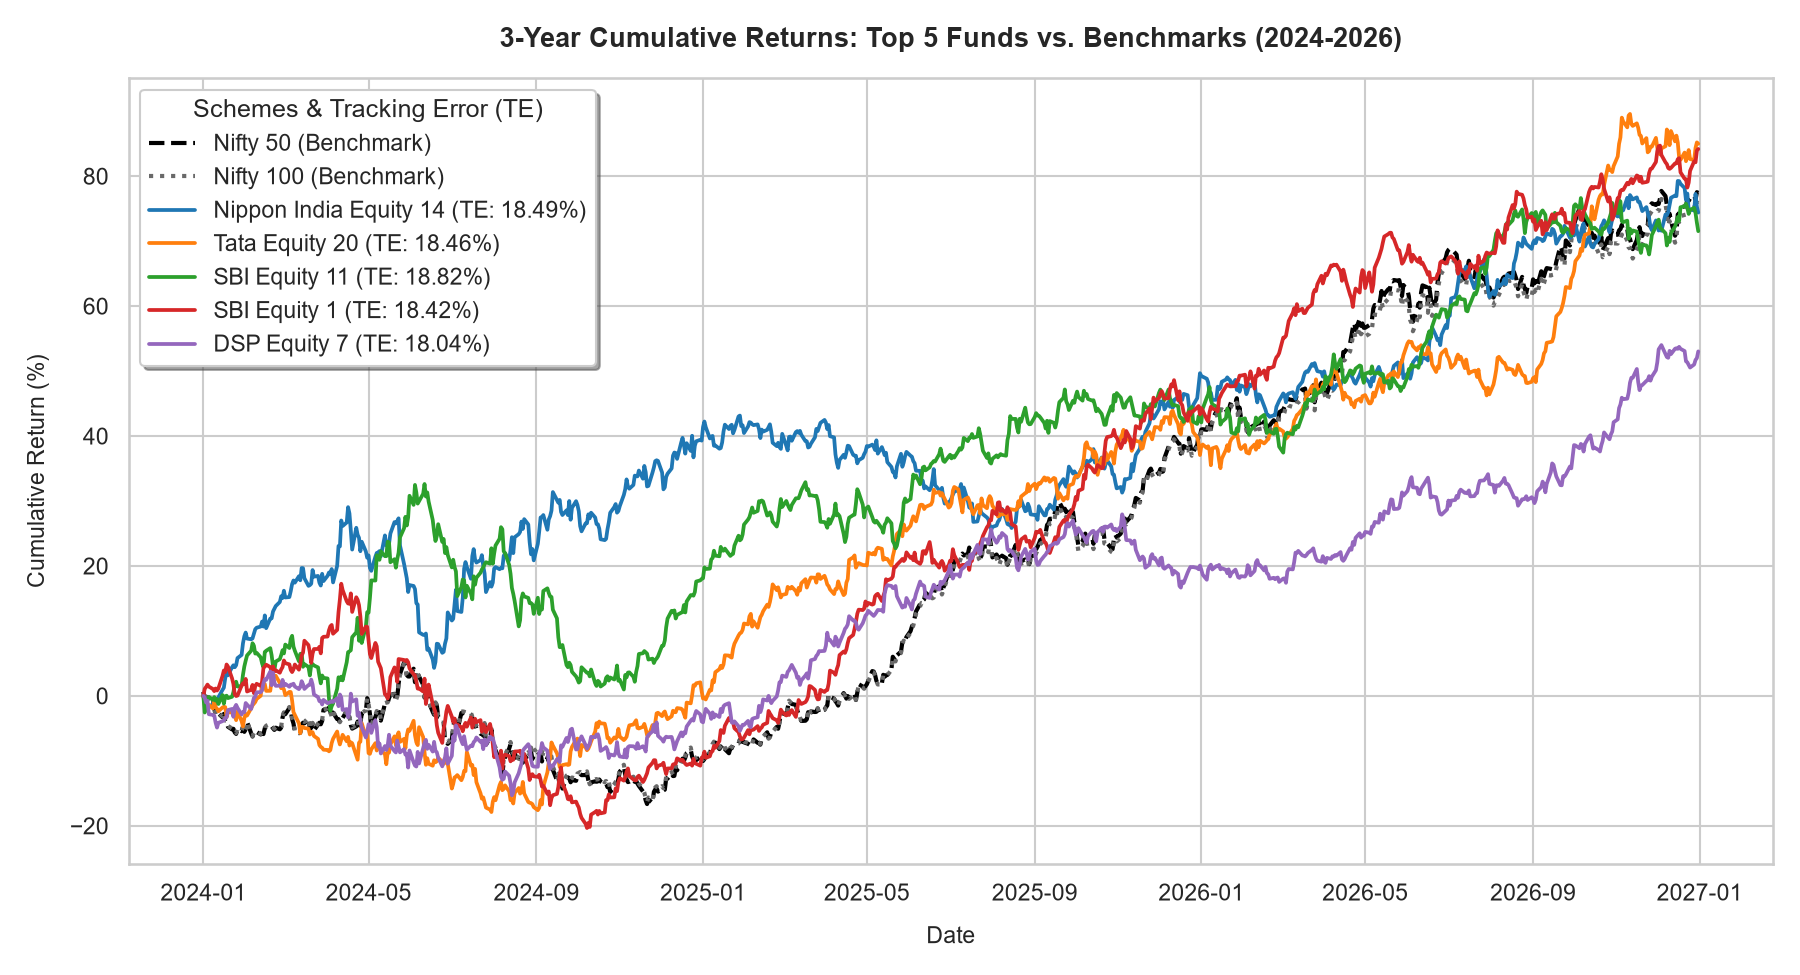

In [9]:
# Display pre-generated chart
from IPython.display import Image, display
chart_path = os.path.join("..", "reports", "figures", "benchmark_comparison.png")
if os.path.exists(chart_path):
    display(Image(filename=chart_path))
else:
    print("Benchmark comparison chart not found. Please run the analytics script.")


---
### Conclusion
This concludes the Advanced Mutual Fund Performance Analytics. The composite scorecard highlights the funds that optimized risk-adjusted returns (high Sharpe/Sortino), generated positive active manager alpha, and minimized downside drawdowns during market corrections.
